In [39]:
import pandas as pd 
import matplotlib.pyplot as plt 

In [40]:
df = pd.read_csv('./data/raw/shopping.csv')

In [41]:
df.head()

,Customer ID,Age,Gender,Item Purchased,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Shipping Type,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,3475,NaN,Male,Jacket,30.904467,Maine,M,Burnt orange,Fall,4.0,Standard,No,0,Credit Card,NaN
1,3698,21.0,Female,Backpack,31.588259,NaN,L,Turquoise,Winter,2.0,Express,No,1,Credit Card,Monthly
2,2756,31.0,Male,Leggings,24.231704,Nevada,M,Terra cotta,Winter,4.0,Standard,No,0,Credit Card,NaN
3,3340,NaN,Male,Pajamas,33.918834,Nebraska,M,Black,Winter,NaN,Standard,No,2,Credit Card,Bi-Weekly
4,3391,38.0,Male,Sunglasses,36.545487,Oregon,S,Aubergine,Summer,NaN,Standard,No,0,Credit Card,NaN


In [42]:
df["Payment Method"].value_counts()
df["Shipping Type"].value_counts()
df['Previous Purchases'].value_counts()

Previous Purchases
0     655
1     473
2     379
3     345
4     273
20    227
5     220
7     187
6     176
8     166
10    124
9     123
11    100
12     91
13     80
14     71
15     53
16     47
18     43
17     38
19     29
Name: count, dtype: int64

In [43]:
df.describe()
df["Review Rating"]

0       4.0
1       2.0
2       4.0
3       NaN
4       NaN
       ... 
3895    NaN
3896    4.0
3897    NaN
3898    NaN
3899    4.0
Name: Review Rating, Length: 3900, dtype: float64

In [44]:

df['Age'] = df['Age'].fillna(0).astype('int64')

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   str    
 3   Item Purchased          3900 non-null   str    
 4   Purchase Amount (USD)   3900 non-null   float64
 5   Location                3510 non-null   str    
 6   Size                    3900 non-null   str    
 7   Color                   3900 non-null   str    
 8   Season                  3900 non-null   str    
 9   Review Rating           1431 non-null   float64
 10  Shipping Type           3900 non-null   str    
 11  Promo Code Used         3900 non-null   str    
 12  Previous Purchases      3900 non-null   int64  
 13  Payment Method          3900 non-null   str    
 14  Frequency of Purchases  1560 non-null   str    
dty

In [45]:


top_products = df.groupby("Gender")['Item Purchased'].value_counts()

top_products_female = top_products["Female"][:5]

In [46]:
top_products_male = top_products["Male"][:5]

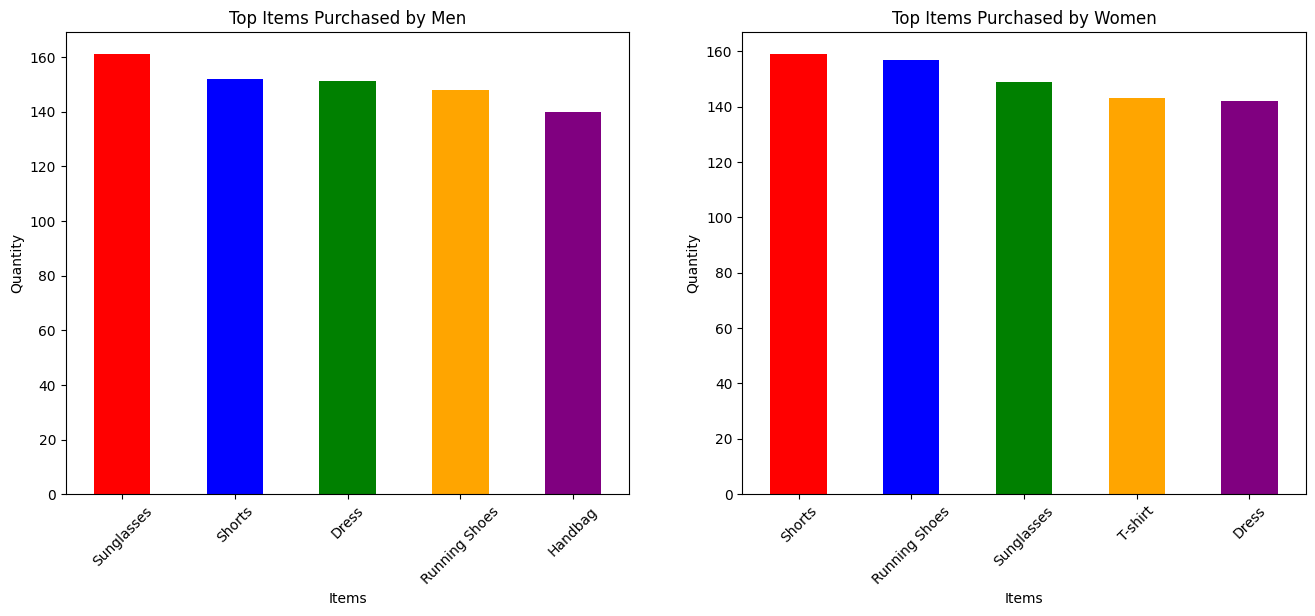

In [54]:
my_colors = ['red', 'blue', 'green', 'orange', 'purple']
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_products_male.plot.bar(color=my_colors, ax=axes[0])
axes[0].set_title("Top Items Purchased by Men")
axes[0].set_xlabel("Items")
axes[0].set_ylabel("Quantity")
axes[0].tick_params(axis='x', rotation=45)

top_products_female.plot.bar(color=my_colors, ax=axes[1])
axes[1].set_title("Top Items Purchased by Women")
axes[1].set_xlabel("Items")
axes[1].set_ylabel("Quantity")
axes[1].tick_params(axis='x', rotation=45)

plt.show()


In [49]:
df['Purchase Amount (USD)'] = df['Purchase Amount (USD)'].__round__(2)



markets_purchasing_power = df.groupby("Location")['Purchase Amount (USD)'].agg(["sum"]).sort_values(by="sum", ascending=False)[:10]
markets_purchasing_power

markets_highest_average = df.groupby("Location")['Purchase Amount (USD)'].agg(["mean"]).sort_values(by="mean", ascending=False)[:10]
markets_highest_average


,mean
Location,
Indiana,43.471690
Hawaii,41.779434
Iowa,41.728769
Missouri,40.847500
Massachusetts,40.517059
South Carolina,40.432500
Florida,40.347213
West Virginia,40.096282
Nebraska,39.946625


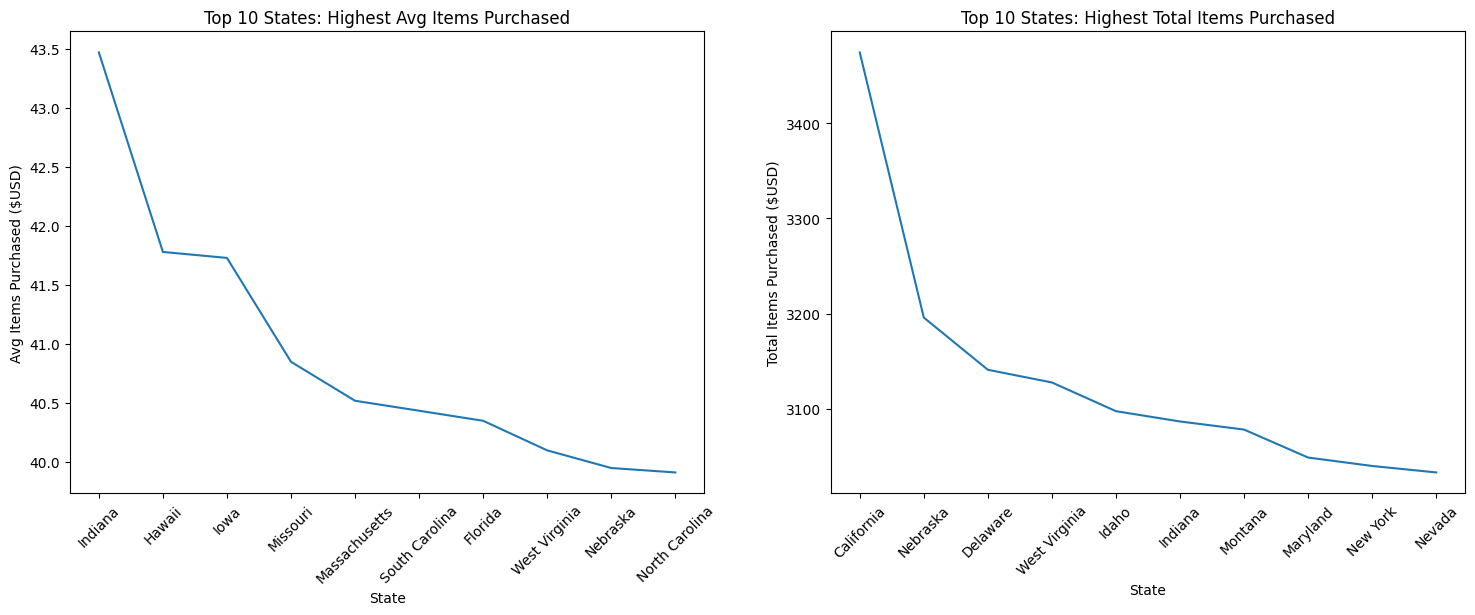

In [53]:
fig, axs = plt.subplots(1, 2, figsize=(18, 6))


axs[0].plot(markets_highest_average['mean'])
axs[0].set_title("Top 10 States: Highest Avg Items Purchased")
axs[0].set_ylabel("Avg Items Purchased ($USD)")
axs[0].set_xlabel("State")
axs[0].tick_params(axis='x', rotation=45)

axs[1].plot(markets_purchasing_power['sum'])
axs[1].set_title("Top 10 States: Highest Total Items Purchased")
axs[1].set_ylabel("Total Items Purchased ($USD)")
axs[1].set_xlabel("State")
axs[1].tick_params(axis='x', rotation=45)

plt.show()



In [ ]:
df['Purchase Amount (USD)'].min()

lower_bucket_range = df[(df["Purchase Amount (USD)"] > 10.00) & (df["Purchase Amount (USD)"] < 24.99)]
middle_bucket_range = df[(df["Purchase Amount (USD)"] > 25.00) & (df["Purchase Amount (USD)"] < 43.99)]
high_bucket_range = df[(df["Purchase Amount (USD)"] > 44.00) & (df["Purchase Amount (USD)"] < 58.99)]
exceptional_bucket_range = df[(df["Purchase Amount (USD)"] > 59.00) & (df["Purchase Amount (USD)"] < 73.99)]

total_items_purchased_high = len(high_bucket_range['Item Purchased'])
total_items_purchased_middle = len(middle_bucket_range['Item Purchased'])
total_items_purchased_lower = len(lower_bucket_range['Item Purchased'])
total_items_purchased_exceptional = len(exceptional_bucket_range['Item Purchased'])

labels = ["low", "mid", "high", "exceptional"]

values = [total_items_purchased_lower, total_items_purchased_middle, total_items_purchased_high, total_items_purchased_exceptional]





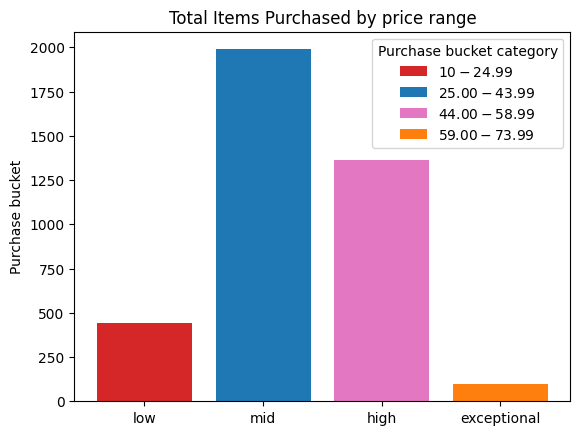

In [ ]:
fig, ax = plt.subplots()

bar_labels = ['$10 - $24.99', '$25.00 - $43.99', '$44.00 - $58.99', '$59.00 - $73.99']
bar_colors = ['tab:red', 'tab:blue', 'tab:pink', 'tab:orange']

ax.bar(labels, values, label=bar_labels, color=bar_colors)

ax.set_ylabel('Purchase bucket')
ax.set_title('Total Items Purchased by price range')
ax.legend(title='Purchase bucket category')

plt.show()

In [ ]:
cleaned_null_review_rating_row = df.dropna(subset="Review Rating")

cleaned_null_review_rating_row.info()

<class 'pandas.DataFrame'>
Index: 1431 entries, 0 to 3899
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             1431 non-null   int64  
 1   Age                     1431 non-null   int64  
 2   Gender                  1431 non-null   str    
 3   Item Purchased          1431 non-null   str    
 4   Purchase Amount (USD)   1431 non-null   float64
 5   Location                1269 non-null   str    
 6   Size                    1431 non-null   str    
 7   Color                   1431 non-null   str    
 8   Season                  1431 non-null   str    
 9   Review Rating           1431 non-null   float64
 10  Shipping Type           1431 non-null   str    
 11  Promo Code Used         1431 non-null   str    
 12  Previous Purchases      1431 non-null   int64  
 13  Payment Method          1431 non-null   str    
 14  Frequency of Purchases  599 non-null    str    
dtypes: 

In [57]:
# plt.figure(figsize=(14,6))
# plt.plot(cleaned_null_review_rating_row["Review Rating"], cleaned_null_review_rating_row["Previous Purchases"])

organized_review_ratings = cleaned_null_review_rating_row.groupby("Review Rating")["Previous Purchases"].agg(["sum", "mean"])
organized_review_ratings.head()


,sum,mean
Review Rating,,
1.0,230,4.693878
2.0,1394,6.394495
3.0,0,0.000000
4.0,5006,7.001399
5.0,3031,6.765625


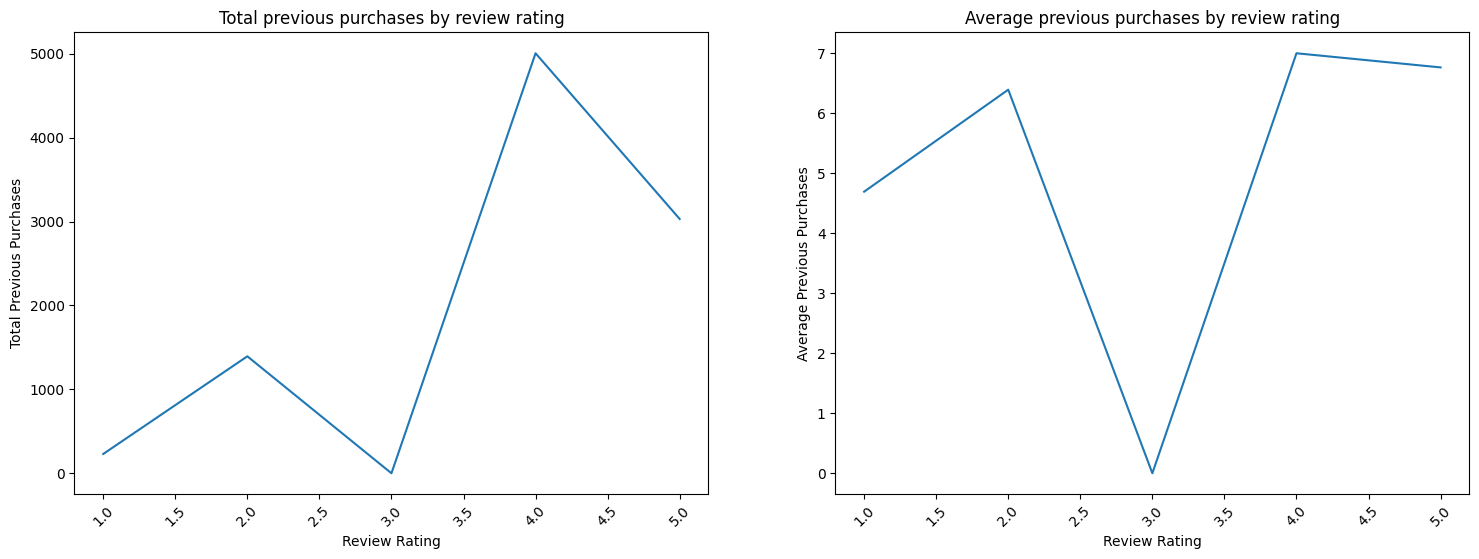

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(18, 6))


axs[0].plot(organized_review_ratings['sum'])
axs[0].set_title("Total previous purchases by review rating")
axs[0].set_ylabel("Total Previous Purchases")
axs[0].set_xlabel("Review Rating")
axs[0].tick_params(axis='x', rotation=45)

axs[1].plot(organized_review_ratings['mean'])
axs[1].set_title("Average previous purchases by review rating")
axs[1].set_ylabel("Average Previous Purchases")
axs[1].set_xlabel("Review Rating")
axs[1].tick_params(axis='x', rotation=45)

plt.show()